# Prevención vial en Sonora con ATUS, últimos 10 años disponibles

Este notebook está preparado para Google Colab y analiza accidentes de tránsito de Sonora usando la base ATUS de INEGI.

Periodo usado: **2015 a 2024**, que corresponde a los últimos 10 años disponibles en los archivos locales del proyecto.

Técnicas aplicadas:

- Análisis exploratorio de datos (EDA)
- Análisis regional y temporal
- Chi-cuadrada y Cramér's V
- Reglas de asociación con Apriori
- Regresión logística
- Random Forest
- Clustering jerárquico
- Series de tiempo exploratorias con ARIMA y Prophet si está disponible

Nota metodológica: la gravedad se construye con heridos/fallecidos o la clasificación del accidente. Por eso, esas variables no se usan como predictoras en los modelos de clasificación para evitar fuga de información.

## 1. Instalación de librerías

En Colab, esta celda instala dependencias que no siempre vienen incluidas. Si estas ejecutando localmente y ya las tienes instaladas, puedes omitirla.

In [1]:
import sys
import subprocess
import importlib.util

def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])

ensure_package("mlxtend")
ensure_package("statsmodels")

# Prophet puede tardar en instalarse. Se intenta usar solo si ya está disponible.

### Explicación

En esta celda preparo las librerías externas que necesito para el análisis. Primero reviso si ya están instaladas y, si no aparecen en el entorno, las instalo automáticamente. Esto me ayuda a que el notebook pueda ejecutarse en Colab sin tener que instalar todo manualmente. En particular, necesito `mlxtend` para las reglas de asociación y `statsmodels` para el análisis de series de tiempo.

## 2. Carga de librerías y configuración

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text

from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid", palette="Set2")


### Explicación

En esta parte cargo las librerías principales del proyecto. Uso `pandas` y `numpy` para manejar los datos, `matplotlib` y `seaborn` para las gráficas, y herramientas estadísticas y de aprendizaje automatico para aplicar los métodos del análisis. También configuro algunos detalles visuales y oculto advertencias para que los resultados del notebook sean más fáciles de leer.

## 3. Configurar fuente de datos

Por defecto, el notebook usa `DATA_SOURCE = "auto"`:

1. Intenta leer los CSV desde GitHub raw.
2. Si GitHub no responde, intenta jsDelivr como espejo CDN del repositorio.
3. Si no hay red disponible, intenta leer archivos locales con la estructura `datos/originales/...`.

Si estas en Colab y aparece `Network is unreachable`, el runtime no tiene salida a internet en ese momento. En ese caso sube la carpeta del proyecto a Colab o monta Google Drive y deja `DATA_SOURCE = "auto"` o cambia a `DATA_SOURCE = "local"`.

In [3]:
DATA_SOURCE = "auto"  # opciones: "auto", "github", "local"
GITHUB_BRANCH = "master"
GITHUB_RAW_BASE = (
    "https://raw.githubusercontent.com/"
    f"62636228/prevencion_vial_sonora_Sheeptech/{GITHUB_BRANCH}"
)
JSDELIVR_BASE = (
    "https://cdn.jsdelivr.net/gh/"
    f"62636228/prevencion_vial_sonora_Sheeptech@{GITHUB_BRANCH}"
)

def find_local_project_dir():
    # Si usas Google Drive, descomenta estas lineas:
    # from google.colab import drive
    # drive.mount("/content/drive")

    candidate_base_dirs = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/content/prevencion_vial_sonora_Sheeptech"),
        Path("/content/drive/MyDrive/prevencion_vial_sonora_Sheeptech"),
    ]
    for base in candidate_base_dirs:
        if (base / "datos" / "originales" / "conjunto_de_datos").exists():
            return base
    return None

DATA_SOURCES = []
if DATA_SOURCE in ("auto", "github"):
    DATA_SOURCES.extend([
        {
            "name": "GitHub raw",
            "data_dir": f"{GITHUB_RAW_BASE}/datos/originales/conjunto_de_datos",
            "cat_dir": f"{GITHUB_RAW_BASE}/datos/originales/catalogos",
        },
        {
            "name": "jsDelivr CDN",
            "data_dir": f"{JSDELIVR_BASE}/datos/originales/conjunto_de_datos",
            "cat_dir": f"{JSDELIVR_BASE}/datos/originales/catalogos",
        },
    ])

if DATA_SOURCE in ("auto", "local"):
    PROJECT_DIR = find_local_project_dir()
    if PROJECT_DIR is not None:
        DATA_SOURCES.append({
            "name": "local",
            "data_dir": PROJECT_DIR / "datos" / "originales" / "conjunto_de_datos",
            "cat_dir": PROJECT_DIR / "datos" / "originales" / "catalogos",
        })

if not DATA_SOURCES:
    raise FileNotFoundError(
        "No hay fuentes de datos disponibles. Si no tienes red, sube la carpeta del proyecto "
        "a Colab o monta Google Drive con datos/originales/conjunto_de_datos."
    )

print("Fuentes configuradas:")
for source in DATA_SOURCES:
    print("-", source["name"], ":", source["data_dir"])

Fuentes configuradas:
- GitHub raw : https://raw.githubusercontent.com/62636228/prevencion_vial_sonora_Sheeptech/master/datos/originales/conjunto_de_datos
- jsDelivr CDN : https://cdn.jsdelivr.net/gh/62636228/prevencion_vial_sonora_Sheeptech@master/datos/originales/conjunto_de_datos
- local : c:\Users\felip\OneDrive\Documentos\prevencion_vial_sonora_Sheeptech\datos\originales\conjunto_de_datos


### Explicación

Aquí configuro de donde se van a leer los datos. Dejo el modo `auto` para que el notebook primero intente tomar los archivos desde GitHub, después pruebe una segúnda fuente en linea y, si no hay conexion, busque los archivos locales en la carpeta del proyecto. Esto es importante porque en Colab a veces puede fallar la conexion, y con esta configuración tengo una alternativa para seguir trabajando.

## 4. Cargar ATUS 2015-2024 y filtrar Sonora

In [4]:
YEARS = list(range(2015, 2025))
SONORA_ID = "26"
ACTIVE_SOURCE = None

def data_path(base_dir, filename):
    if isinstance(base_dir, str):
        return f"{base_dir}/{filename}"
    return base_dir / filename

def read_csv_clean(path_or_url):
    df = pd.read_csv(
        path_or_url,
        dtype=str,
        skipinitialspace=True,
        encoding="utf-8",
        low_memory=False,
        index_col=False,
    )
    df.columns = df.columns.str.strip()
    for col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"nan": np.nan, "None": np.nan})
    return df

def read_csv_from_sources(filename, folder):
    global ACTIVE_SOURCE

    sources_to_try = []
    if ACTIVE_SOURCE is not None:
        sources_to_try.append(ACTIVE_SOURCE)
    sources_to_try.extend([source for source in DATA_SOURCES if source is not ACTIVE_SOURCE])

    errors = []
    for source in sources_to_try:
        base_dir = source["data_dir"] if folder == "data" else source["cat_dir"]
        path = data_path(base_dir, filename)
        if isinstance(path, Path) and not path.exists():
            errors.append(f'{source["name"]}: no existe {path}')
            continue
        try:
            df = read_csv_clean(path)
            ACTIVE_SOURCE = source
            return df
        except Exception as exc:
            errors.append(f'{source["name"]}: {type(exc).__name__}: {exc}')

    raise RuntimeError(
        "No se pudieron leer los datos. Si ves 'Network is unreachable', el entorno no tiene internet. "
        "Sube la carpeta del proyecto a Colab o monta Google Drive y usa DATA_SOURCE = 'local'.\n\n"
        + "\n".join(errors[-6:])
    )

def read_atus_year(year):
    return read_csv_from_sources(f"atus_anual_{year}.csv", folder="data")

frames = []
for year in YEARS:
    tmp = read_atus_year(year)
    tmp = tmp[tmp["ID_ENTIDAD"].astype(str).str.strip().str.zfill(2) == SONORA_ID].copy()
    frames.append(tmp)

atus = pd.concat(frames, ignore_index=True)

mun = read_csv_from_sources("tc_municipio.csv", folder="cat")
mun["ID_ENTIDAD"] = mun["ID_ENTIDAD"].str.zfill(2)
mun["ID_MUNICIPIO"] = mun["ID_MUNICIPIO"].str.zfill(3)

atus["ID_ENTIDAD"] = atus["ID_ENTIDAD"].astype(str).str.strip().str.zfill(2)
atus["ID_MUNICIPIO"] = atus["ID_MUNICIPIO"].astype(str).str.strip().str.zfill(3)

# ATUS incluye registros "Certificado cero" para indicar ausencia de accidente.
# Se excluyen porque el proyecto analiza accidentes ocurridos.
atus = atus[atus["TIPACCID"].ne("Certificado cero")].copy()

atus = atus.merge(
    mun[["ID_ENTIDAD", "ID_MUNICIPIO", "NOM_MUNICIPIO"]],
    on=["ID_ENTIDAD", "ID_MUNICIPIO"],
    how="left",
)

print("Fuente activa:", ACTIVE_SOURCE["name"])
print("Registros Sonora 2015-2024:", len(atus))
display(atus.head())

Fuente activa: GitHub raw
Registros Sonora 2015-2024: 183911


,COBERTURA,ID_ENTIDAD,ID_MUNICIPIO,ANIO,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,URBANA,SUBURBANA,TIPACCID,AUTOMOVIL,CAMPASAJ,MICROBUS,PASCAMION,OMNIBUS,TRANVIA,CAMIONETA,CAMION,TRACTOR,FERROCARRI,MOTOCICLET,BICICLETA,OTROVEHIC,CAUSAACCI,CAPAROD,SEXO,ALIENTO,CINTURON,ID_EDAD,CONDMUERTO,CONDHERIDO,PASAMUERTO,PASAHERIDO,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS,NOM_MUNICIPIO
0,Municipal,26,002,2015,01,14,25,26,Lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con vehículo automotor,2,0,0,0,0,0,0,0,0,0,0,0,0,Conductor,Pavimentada,Hombre,No,Se ignora,47,0,0,0,2,0,0,0,0,0,0,0,0,No fatal,Cifras Revisadas,Agua Prieta
1,Municipal,26,002,2015,01,17,16,1,Jueves,Accidente en intersección,Sin accidente en esta zona,Colisión con motocicleta,1,0,0,0,0,0,0,0,0,0,1,0,0,Conductor,No Pavimentada,Hombre,No,Se ignora,18,0,1,0,1,0,2,0,0,0,0,0,0,No fatal,Cifras Revisadas,Agua Prieta
2,Municipal,26,002,2015,01,7,40,28,Miércoles,Accidente en intersección,Sin accidente en esta zona,Colisión con vehículo automotor,2,0,0,0,0,0,0,0,0,0,0,0,0,Conductor,Pavimentada,Hombre,No,Se ignora,16,0,0,0,0,0,0,0,0,0,0,0,0,Sólo daños,Cifras Revisadas,Agua Prieta
3,Municipal,26,002,2015,01,23,0,30,Viernes,Accidente en intersección,Sin accidente en esta zona,Colisión con peatón (atropellamiento),1,0,0,0,0,0,0,0,0,0,0,0,0,Conductor,Pavimentada,Hombre,No,Se ignora,58,0,0,0,0,0,1,0,0,0,0,0,0,No fatal,Cifras Revisadas,Agua Prieta
4,Municipal,26,002,2015,01,13,0,21,Miércoles,Accidente en intersección,Sin accidente en esta zona,Colisión con vehículo automotor,2,0,0,0,0,0,0,0,0,0,0,0,0,Conductor,Pavimentada,Hombre,No,Se ignora,18,0,0,0,0,0,0,0,0,0,0,0,0,Sólo daños,Cifras Revisadas,Agua Prieta


### Explicación

En esta celda cargo los archivos de ATUS de 2015 a 2024 y filtro únicamente los registros de Sonora, usando la clave `26`. También limpio los textos, junto los diez años en una sola tabla y agrego el nombre del municipio con el catálogo correspondiente. Además, elimino los registros de `Certificado cero`, porque esos no representan accidentes reales y podrían afectar el análisis.

## 5. Limpieza, variables derivadas y regiones

In [5]:
dead_cols = ["CONDMUERTO", "PASAMUERTO", "PEATMUERTO", "CICLMUERTO", "OTROMUERTO", "NEMUERTO"]
injury_cols = ["CONDHERIDO", "PASAHERIDO", "PEATHERIDO", "CICLHERIDO", "OTROHERIDO", "NEHERIDO"]
vehicle_cols = [
    "AUTOMOVIL", "CAMPASAJ", "MICROBUS", "PASCAMION", "OMNIBUS", "TRANVIA",
    "CAMIONETA", "CAMION", "TRACTOR", "FERROCARRI", "MOTOCICLET", "BICICLETA", "OTROVEHIC"
]
numeric_cols = dead_cols + injury_cols + vehicle_cols

for col in numeric_cols + ["ANIO", "ID_HORA", "ID_MINUTO", "ID_DIA", "ID_EDAD"]:
    if col in atus.columns:
        atus[col] = pd.to_numeric(atus[col], errors="coerce")

atus["TOTAL_MUERTOS"] = atus[dead_cols].fillna(0).sum(axis=1)
atus["TOTAL_HERIDOS"] = atus[injury_cols].fillna(0).sum(axis=1)
atus["TOTAL_VICTIMAS"] = atus["TOTAL_MUERTOS"] + atus["TOTAL_HERIDOS"]
atus["TOTAL_VEHICULOS"] = atus[vehicle_cols].fillna(0).sum(axis=1)
atus["INVOLUCRA_MOTO"] = (atus["MOTOCICLET"].fillna(0) > 0).astype(int)
atus["INVOLUCRA_BICI"] = (atus["BICICLETA"].fillna(0) > 0).astype(int)

atus["GRAVE_BIN"] = (
    (atus["TOTAL_VICTIMAS"] > 0) |
    (atus["CLASACC"].isin(["Fatal", "No fatal"]))
).astype(int)
atus["NIVEL_GRAVEDAD"] = np.select(
    [atus["TOTAL_MUERTOS"] > 0, atus["TOTAL_HERIDOS"] > 0],
    ["Fatal", "Con heridos"],
    default="Solo daños",
)

region_map = {
    "030": "Hermosillo",
    "002": "Frontera", "019": "Frontera", "027": "Frontera", "035": "Frontera",
    "039": "Frontera", "041": "Frontera", "043": "Frontera", "055": "Frontera",
    "058": "Frontera", "059": "Frontera", "060": "Frontera", "067": "Frontera",
    "004": "Costa y desierto", "007": "Costa y desierto", "017": "Costa y desierto",
    "046": "Costa y desierto", "047": "Costa y desierto", "048": "Costa y desierto",
    "064": "Costa y desierto", "065": "Costa y desierto", "070": "Costa y desierto",
    "001": "Centro", "006": "Centro", "013": "Centro", "014": "Centro", "016": "Centro",
    "020": "Centro", "021": "Centro", "022": "Centro", "023": "Centro", "024": "Centro",
    "028": "Centro", "034": "Centro", "037": "Centro", "038": "Centro", "045": "Centro",
    "050": "Centro", "053": "Centro", "054": "Centro", "056": "Centro", "057": "Centro",
    "063": "Centro", "066": "Centro", "068": "Centro",
    "003": "Sur y Valle", "012": "Sur y Valle", "018": "Sur y Valle", "025": "Sur y Valle",
    "026": "Sur y Valle", "029": "Sur y Valle", "033": "Sur y Valle", "042": "Sur y Valle",
    "049": "Sur y Valle", "051": "Sur y Valle", "071": "Sur y Valle", "072": "Sur y Valle",
    "005": "Sierra", "008": "Sierra", "009": "Sierra", "010": "Sierra", "011": "Sierra",
    "015": "Sierra", "031": "Sierra", "032": "Sierra", "040": "Sierra", "044": "Sierra",
    "052": "Sierra", "061": "Sierra", "062": "Sierra", "069": "Sierra",
}
atus["REGION"] = atus["ID_MUNICIPIO"].map(region_map).fillna("Otros municipios")

atus["MES_NUM"] = pd.to_numeric(atus["MES"], errors="coerce")
atus["DIA_VALIDO"] = atus["ID_DIA"].where(atus["ID_DIA"].between(1, 31))
atus["FECHA"] = pd.to_datetime(
    dict(year=atus["ANIO"], month=atus["MES_NUM"], day=atus["DIA_VALIDO"]),
    errors="coerce",
)
atus["FECHA_MES"] = pd.to_datetime(
    dict(year=atus["ANIO"], month=atus["MES_NUM"], day=1),
    errors="coerce",
)

atus["HORA_VALIDA"] = atus["ID_HORA"].where(atus["ID_HORA"].between(0, 23))
atus["RANGO_HORA"] = pd.cut(
    atus["HORA_VALIDA"],
    bins=[-0.1, 5, 11, 17, 23],
    labels=["Madrugada", "Mañana", "Tarde", "Noche"],
)

day_map = {
    "lunes": "Lunes",
    "martes": "Martes",
    "miercoles": "Miércoles",
    "miércoles": "Miércoles",
    "jueves": "Jueves",
    "viernes": "Viernes",
    "sabado": "Sábado",
    "sábado": "Sábado",
    "domingo": "Domingo",
}
atus["DIASEMANA"] = (
    atus["DIASEMANA"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(day_map)
)

day_order = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
hour_order = ["Madrugada", "Mañana", "Tarde", "Noche"]

atus["EDAD_CONDUCTOR"] = atus["ID_EDAD"].where(atus["ID_EDAD"].between(12, 98))

print(atus[["ANIO", "NOM_MUNICIPIO", "REGION", "TIPACCID", "CAUSAACCI", "NIVEL_GRAVEDAD", "GRAVE_BIN"]].head())
print("\nDistribución de gravedad:")
display(atus["NIVEL_GRAVEDAD"].value_counts(dropna=False))


   ANIO NOM_MUNICIPIO    REGION                               TIPACCID  \
0  2015   Agua Prieta  Frontera        Colisión con vehículo automotor   
1  2015   Agua Prieta  Frontera               Colisión con motocicleta   
2  2015   Agua Prieta  Frontera        Colisión con vehículo automotor   
3  2015   Agua Prieta  Frontera  Colisión con peatón (atropellamiento)   
4  2015   Agua Prieta  Frontera        Colisión con vehículo automotor   

   CAUSAACCI NIVEL_GRAVEDAD  GRAVE_BIN  
0  Conductor    Con heridos          1  
1  Conductor    Con heridos          1  
2  Conductor     Solo daños          0  
3  Conductor    Con heridos          1  
4  Conductor     Solo daños          0  

Distribución de gravedad:


NIVEL_GRAVEDAD
Solo daños     152659
Con heridos     29277
Fatal            1975
Name: count, dtype: int64

### Explicación

Aquí preparo las variables que voy a usar durante el análisis. Convierto columnas numéricas, calculo el total de personas heridas, fallecidas y víctimás, y creo variables como accidente grave, nivel de gravedad, presencia de motocicleta o bicicleta y total de vehículos. También asigno cada municipio a una región de Sonora y construyo variables de fecha y horario para poder comparar patrónes por tiempo y zona.

## 6. Análisis exploratorio de datos

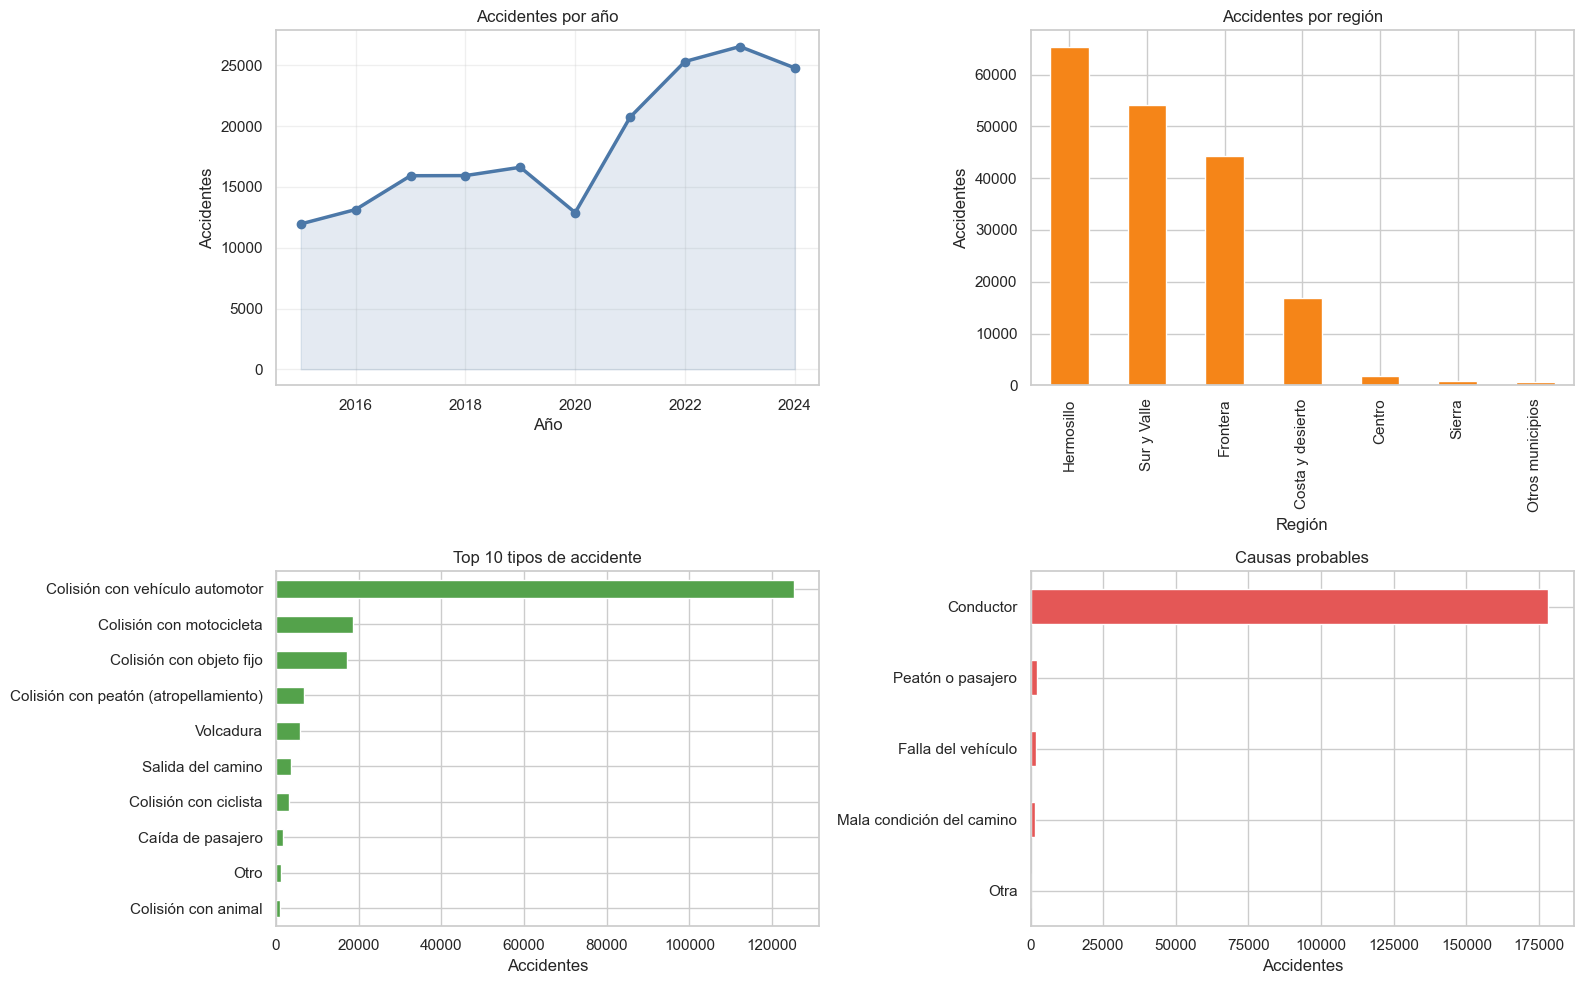

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

annual_counts = atus["ANIO"].value_counts().sort_index()
axes[0, 0].plot(annual_counts.index, annual_counts.values, marker="o", linewidth=2.5, color="#4C78A8")
axes[0, 0].fill_between(annual_counts.index, annual_counts.values, color="#4C78A8", alpha=0.15)
axes[0, 0].set_title("Accidentes por año")
axes[0, 0].set_xlabel("Año")
axes[0, 0].set_ylabel("Accidentes")
axes[0, 0].grid(True, alpha=0.3)

atus["REGION"].value_counts().plot(kind="bar", ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Accidentes por región")
axes[0, 1].set_xlabel("Región")
axes[0, 1].set_ylabel("Accidentes")

atus["TIPACCID"].value_counts().head(10).sort_values().plot(kind="barh", ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Top 10 tipos de accidente")
axes[1, 0].set_xlabel("Accidentes")
axes[1, 0].set_ylabel("")

atus["CAUSAACCI"].value_counts().sort_values().plot(kind="barh", ax=axes[1, 1], color="#E45756")
axes[1, 1].set_title("Causas probables")
axes[1, 1].set_xlabel("Accidentes")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

### Explicación

En esta celda hago una primera exploración visual de los accidentes. Grafico cuantos accidentes hay por año, por región, por tipo de accidente y por causa probable. Esto me sirve para tener una idea general del comportamiento de los datos antes de aplicar métodos más avanzados.

### Interpretacion

En estas graficas observo que los accidentes aumentan con fuerza despues de 2020. El punto mas alto del periodo aparece en 2023, con 26,557 registros, y en 2024 hay una disminucion a 24,799 accidentes; aun asi, 2024 sigue siendo uno de los años con mayor volumen de la decada. Por region, Hermosillo concentra la mayor cantidad de casos con 65,252 accidentes, seguido de Sur y Valle con 54,154 y Frontera con 44,264. Esto indica que las zonas con mas movilidad urbana, actividad economica y flujo vehicular concentran gran parte del problema vial.

Tambien se ve que el tipo de accidente dominante es la colision con vehiculo automotor, con 125,202 casos. Despues aparecen la colision con motocicleta, con 18,531 casos, y la colision con objeto fijo, con 17,205. En cuanto a la causa probable, la categoria Conductor concentra 178,145 registros, por lo que las estrategias preventivas deben enfocarse principalmente en comportamiento vial, velocidad, distancia de seguridad, distracciones y respeto a senalamientos.


In [7]:
region_summary = (
    atus.groupby("REGION")
    .agg(
        accidentes=("GRAVE_BIN", "size"),
        accidentes_graves=("GRAVE_BIN", "sum"),
        pct_graves=("GRAVE_BIN", "mean"),
        heridos=("TOTAL_HERIDOS", "sum"),
        fallecidos=("TOTAL_MUERTOS", "sum"),
    )
    .sort_values("accidentes", ascending=False)
)
region_summary["pct_graves"] = (region_summary["pct_graves"] * 100).round(2)
display(region_summary)

top_municipios = (
    atus.groupby("NOM_MUNICIPIO")
    .agg(accidentes=("GRAVE_BIN", "size"), graves=("GRAVE_BIN", "sum"), fallecidos=("TOTAL_MUERTOS", "sum"))
    .sort_values("accidentes", ascending=False)
    .head(15)
)
display(top_municipios)

,accidentes,accidentes_graves,pct_graves,heridos,fallecidos
REGION,,,,,
Hermosillo,65252,8736,13.39,10563,480
Sur y Valle,54154,11436,21.12,14403,783
Frontera,44264,7415,16.75,9671,499
Costa y desierto,16943,2935,17.32,4035,305
Centro,1872,419,22.38,605,99
Sierra,763,185,24.25,249,44
Otros municipios,663,126,19.00,160,11


,accidentes,graves,fallecidos
NOM_MUNICIPIO,,,
Hermosillo,65252,8736,480
Cajeme,32686,3487,219
San Luis Río Colorado,31719,3694,227
Guaymas,10795,3415,90
Puerto Peñasco,9007,964,76
Nogales,6881,2366,135
Caborca,6059,1637,162
Empalme,2591,1111,51
Navojoa,2585,986,89


### Explicación

Aquí resumo los accidentes por región y por municipio. Calculo el total de accidentes, cuantos fueron graves, el porcentaje de gravedad, el número de heridos y el número de fallecidos. Con estas tablas puedo identificar que zonas concentran más accidentes y cuales tienen mayor impacto en personas lesionadas o fallecidas.

### Interpretacion

En la tabla por region se confirma que Hermosillo tiene el mayor volumen de accidentes, pero no el mayor porcentaje de gravedad. La Sierra presenta la proporcion mas alta de accidentes graves, con 24.25%, seguida del Centro con 22.38% y Sur y Valle con 21.12%. Esto significa que algunas regiones con pocos accidentes pueden tener una proporcion alta de casos con heridos o fallecidos.

A nivel municipal, Hermosillo, Cajeme y San Luis Rio Colorado concentran la mayor cantidad de accidentes. Sin embargo, municipios como Guaymas, Nogales, Caborca, Empalme, Navojoa, Bacum y Etchojoa muestran cantidades importantes de accidentes graves o fallecidos. Por eso, la prevencion no debe priorizar solamente los municipios con mas registros totales, sino tambien aquellos donde la gravedad proporcional o el numero de victimas es relevante.


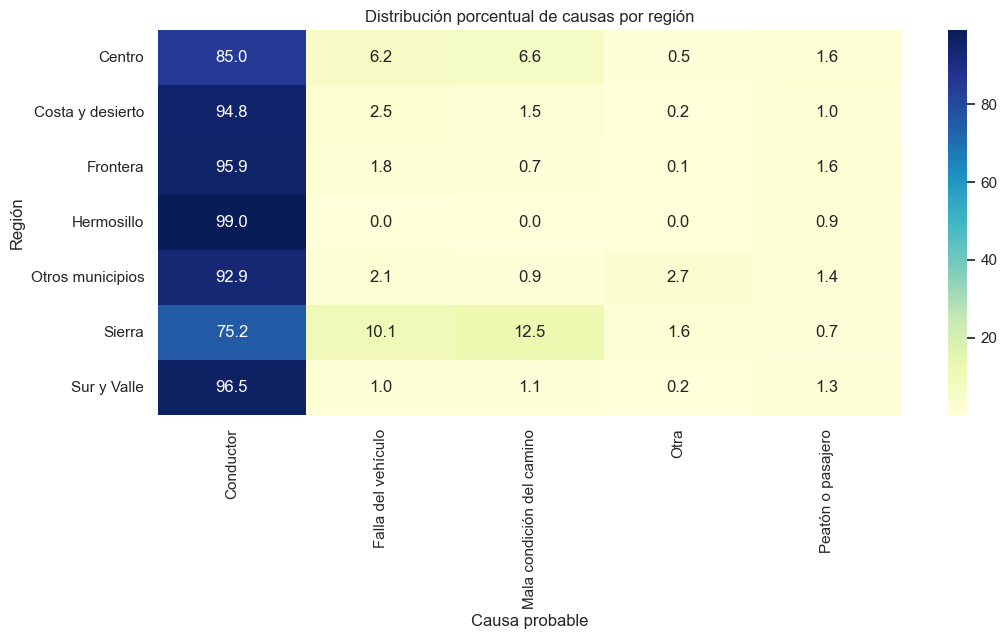

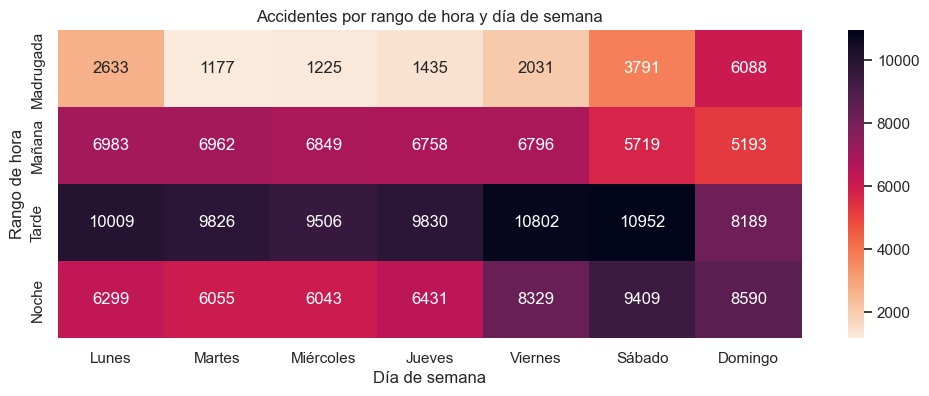

In [8]:
heat_region_cause = pd.crosstab(atus["REGION"], atus["CAUSAACCI"], normalize="index") * 100
plt.figure(figsize=(12, 5))
sns.heatmap(heat_region_cause, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Distribución porcentual de causas por región")
plt.xlabel("Causa probable")
plt.ylabel("Región")
plt.show()

heat_hour_day = pd.crosstab(atus["RANGO_HORA"], atus["DIASEMANA"])
heat_hour_day = heat_hour_day.reindex(index=hour_order, columns=day_order, fill_value=0)

plt.figure(figsize=(12, 4))
sns.heatmap(heat_hour_day, annot=True, fmt=".0f", cmap="rocket_r")
plt.title("Accidentes por rango de hora y día de semana")
plt.xlabel("Día de semana")
plt.ylabel("Rango de hora")
plt.show()

### Explicación

En esta parte uso mapas de calor para comparar patrónes. El primer mapa muestra que causas son más comunes en cada región, usando porcentajes para que la comparación sea más justa. El segúndo mapa cruza el rango de hora con el día de la semana, lo que me permite detectar momentos donde se concentran más accidentes.

### Interpretacion

El mapa de calor por region muestra que la causa Conductor domina en todas las regiones. En Hermosillo representa aproximadamente 99.03% de los casos y en Sur y Valle 96.48%. Aunque en la Sierra baja a 75.23%, sigue siendo la causa principal; ademas, en esa region aparecen con mas peso la mala condicion del camino y las fallas del vehiculo. Esto indica que la prevencion debe combinar educacion vial y vigilancia con revision de condiciones viales en zonas donde la infraestructura puede influir mas.

El segundo mapa de calor muestra que la mayor concentracion ocurre en la tarde del sabado, con 10,952 accidentes, seguida muy de cerca por la tarde del viernes, con 10,802. Esto sugiere que los horarios de salida laboral, actividad comercial y movilidad de fin de semana son momentos criticos. Una estrategia preventiva podria reforzar vigilancia y campanas durante las tardes, especialmente viernes y sabado.


## 7. Chi-cuadrada y Cramér's V


In [9]:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    if n == 0:
        return np.nan
    r, k = confusion_matrix.shape
    return np.sqrt((chi2 / n) / max(min(k - 1, r - 1), 1))

def chi_square_report(df, var_a, var_b):
    table = pd.crosstab(df[var_a], df[var_b])
    chi2, p, dof, expected = chi2_contingency(table)
    cv = cramers_v(table)
    return {
        "variable_1": var_a,
        "variable_2": var_b,
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "cramers_v": cv,
        "tabla": table,
    }

pairs = [
    ("REGION", "NIVEL_GRAVEDAD"),
    ("REGION", "CAUSAACCI"),
    ("REGION", "TIPACCID"),
    ("RANGO_HORA", "NIVEL_GRAVEDAD"),
    ("DIASEMANA", "NIVEL_GRAVEDAD"),
]

results = []
for a, b in pairs:
    result = chi_square_report(atus.dropna(subset=[a, b]), a, b)
    results.append({k: v for k, v in result.items() if k != "tabla"})

chi_results = pd.DataFrame(results).sort_values("cramers_v", ascending=False)
display(chi_results)

,variable_1,variable_2,chi2,p_value,dof,cramers_v
2,REGION,TIPACCID,22705.643853,0.000000e+00,66,0.143446
1,REGION,CAUSAACCI,6156.486922,0.000000e+00,24,0.091481
0,REGION,NIVEL_GRAVEDAD,1676.951893,0.000000e+00,12,0.067521
3,RANGO_HORA,NIVEL_GRAVEDAD,1008.417798,1.351360e-214,6,0.052360
4,DIASEMANA,NIVEL_GRAVEDAD,450.349315,7.961830e-89,12,0.034991


### Explicación

Aquí aplico pruebas estadísticas para revisar si algunas variables categóricas están relacionadas entre si. Uso Chi-cuadrada para saber si existe dependencia entre variables como región y gravedad, y Cramér's V para medir que tan fuerte es esa relación. Esto me ayuda a respaldar con evidencia estadística las diferencias que observo en las tablas y gráficas.

### Interpretacion

Los resultados de Chi-cuadrada muestran valores p muy bajos, por lo que las variables analizadas no parecen comportarse de manera independiente. La asociacion mas fuerte dentro de estas pruebas aparece entre region y tipo de accidente, con Cramer's V de 0.143. Aunque no es una asociacion alta, si indica que el tipo de accidente cambia segun la zona del estado.

Tambien hay asociacion entre region y causa probable, region y nivel de gravedad, rango de hora y gravedad, y dia de la semana y gravedad. Estos resultados respaldan la idea de que el analisis regional y temporal es necesario, porque los accidentes no se distribuyen igual en todas las zonas ni en todos los momentos.


## 8. Reglas de asociación con Apriori

In [10]:
assoc = atus.copy()
assoc["GRAVEDAD"] = np.where(assoc["GRAVE_BIN"] == 1, "Gravedad=Alta", "Gravedad=Baja")
assoc["REGION_ITEM"] = "Region=" + assoc["REGION"].astype(str)
assoc["TIPO_ITEM"] = "Tipo=" + assoc["TIPACCID"].astype(str)
assoc["CAUSA_ITEM"] = "Causa=" + assoc["CAUSAACCI"].astype(str)
assoc["HORA_ITEM"] = "Hora=" + assoc["RANGO_HORA"].astype(str)
assoc["DIA_ITEM"] = "Dia=" + assoc["DIASEMANA"].astype(str)
assoc["MES_ITEM"] = "Mes=" + assoc["MES"].astype(str)

item_cols = ["REGION_ITEM", "TIPO_ITEM", "CAUSA_ITEM", "HORA_ITEM", "DIA_ITEM", "MES_ITEM", "GRAVEDAD"]
transactions = assoc[item_cols].fillna("No especificado")

one_hot = pd.get_dummies(transactions.stack()).groupby(level=0).max().astype(bool)

min_support = 0.02
frequent = apriori(one_hot, min_support=min_support, use_colnames=True)
rules = association_rules(frequent, metric="confidence", min_threshold=0.45)

rules_graves = rules[
    rules["consequents"].apply(lambda x: "Gravedad=Alta" in x)
].copy()

rules_graves = rules_graves.sort_values(["lift", "confidence", "support"], ascending=False)
display(rules_graves[["antecedents", "consequents", "support", "confidence", "lift"]].head(20))

,antecedents,consequents,support,confidence,lift
50,frozenset({Tipo=Colisión con peatón (atropella...,frozenset({Gravedad=Alta}),0.037154,1.000000,5.884775
194,frozenset({Tipo=Colisión con peatón (atropella...,frozenset({Gravedad=Alta}),0.026138,1.000000,5.884775
196,frozenset({Tipo=Colisión con peatón (atropella...,"frozenset({Causa=Conductor, Gravedad=Alta})",0.026138,0.703498,4.583427


### Explicación

En esta celda aplico reglas de asociación con Apriori. Primero convierto cada accidente en un conjunto de características, como región, tipo de accidente, causa, hora, día, mes y gravedad. Después busco combinaciones frecuentes que terminen en `Gravedad=Alta`. Estas reglas son útiles porque muestran patrónes fáciles de interpretar para proponer acciones preventivas.

### Interpretación

Las reglas de asociación muestran que la colisión con peatón aparece fuertemente relacionada con la gravedad alta. La regla `Tipo=Colisión con peatón` hacia `Gravedad=Alta` tiene confianza de 1.0 y lift de 5.88, lo que significa que cuando ocurre este tipo de accidente, el caso tiende a clasificarse como grave con mucha mayor frecuencia que el promedio.

Este resultado es importante para la prevención porque los atropellamientos requieren medidas específicas: protección peatonal, cruces seguros, reducción de velocidad, señalización visible y vigilancia en zonas con alta presencia de peatones.

## 9. Modelos de clasificación de gravedad

In [11]:
# No usar TOTAL_HERIDOS, TOTAL_MUERTOS, TOTAL_VICTIMAS ni CLASACC como predictores,
# porque se usan para construir la variable objetivo GRAVE_BIN.
model_df = atus.copy()
model_df = model_df.dropna(subset=["GRAVE_BIN"])

categorical_features = [
    "REGION", "NOM_MUNICIPIO", "MES", "DIASEMANA", "RANGO_HORA",
    "TIPACCID", "CAUSAACCI", "CAPAROD", "SEXO", "ALIENTO", "CINTURON"
]
numeric_features = ["EDAD_CONDUCTOR", "TOTAL_VEHICULOS", "INVOLUCRA_MOTO", "INVOLUCRA_BICI"]

X = model_df[categorical_features + numeric_features]
y = model_df["GRAVE_BIN"].astype(int)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
        ]), categorical_features),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
    ]
)

stratify = y if y.nunique() == 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=stratify
)

print("Distribucion del objetivo:")
display(y.value_counts(normalize=True).rename("proporcion"))

Distribucion del objetivo:


GRAVE_BIN
0    0.83007
1    0.16993
Name: proporcion, dtype: float64

### Explicación

Aquí preparo los datos para los modelos de clasificación. La variable objetivo es si el accidente fue grave o no grave. También separo variables categóricas y numéricas, y dejo fuera columnas como heridos, fallecidos y clasificación del accidente porque se usan para construir la gravedad. Si las usara como predictores, el modelo estaría recibiendo la respuesta de forma indirecta.

### Modelo KNN linea base

Agrego K-Nearest Neighbors como linea base del curso. Como KNN compara cada caso contra observaciones cercanas y el dataset es grande, lo entreno y evaluo con muestras estratificadas para mantenerlo ejecutable en Colab sin cambiar la preparacion general de datos.


KNN linea base
Filas entrenamiento KNN: 15000 Filas prueba KNN: 10000
Accuracy: 0.8615
              precision    recall  f1-score   support

    No grave       0.88      0.96      0.92      8301
       Grave       0.66      0.38      0.48      1699

    accuracy                           0.86     10000
   macro avg       0.77      0.67      0.70     10000
weighted avg       0.85      0.86      0.85     10000



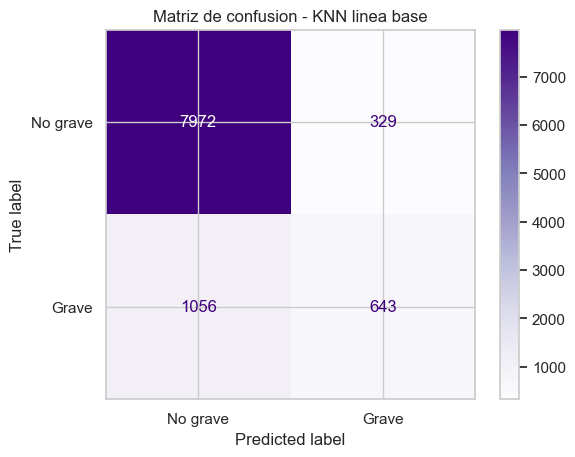

In [12]:
MAX_KNN_TRAIN_ROWS = 15000
MAX_KNN_TEST_ROWS = 10000

if len(X_train) > MAX_KNN_TRAIN_ROWS:
    X_knn_train, _, y_knn_train, _ = train_test_split(
        X_train,
        y_train,
        train_size=MAX_KNN_TRAIN_ROWS,
        random_state=42,
        stratify=y_train,
    )
else:
    X_knn_train, y_knn_train = X_train, y_train

if len(X_test) > MAX_KNN_TEST_ROWS:
    X_knn_test, _, y_knn_test, _ = train_test_split(
        X_test,
        y_test,
        train_size=MAX_KNN_TEST_ROWS,
        random_state=42,
        stratify=y_test,
    )
else:
    X_knn_test, y_knn_test = X_test, y_test

knn_model = Pipeline([
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=5, weights="distance")),
])

knn_model.fit(X_knn_train, y_knn_train)
knn_pred = knn_model.predict(X_knn_test)
knn_score = knn_model.predict_proba(X_knn_test)[:, 1]

print("KNN linea base")
print("Filas entrenamiento KNN:", len(X_knn_train), "Filas prueba KNN:", len(X_knn_test))
print("Accuracy:", round(accuracy_score(y_knn_test, knn_pred), 4))
print(classification_report(y_knn_test, knn_pred, target_names=["No grave", "Grave"]))

ConfusionMatrixDisplay.from_predictions(y_knn_test, knn_pred, display_labels=["No grave", "Grave"], cmap="Purples")
plt.title("Matriz de confusion - KNN linea base")
plt.show()


### Interpretacion

KNN se incluye para cumplir la comparacion con un metodo basado en vecinos cercanos. En este problema funciona como referencia, pero no se espera que sea el modelo recomendado porque hay muchas variables categoricas codificadas y un volumen alto de registros. Su utilidad principal es mostrar si un metodo simple por cercania logra competir contra modelos mas adecuados para datos mixtos, como Regresion Logistica y Random Forest.


Regresión logística
Accuracy: 0.8163
              precision    recall  f1-score   support

    No grave       0.94      0.83      0.88     38165
       Grave       0.47      0.75      0.58      7813

    accuracy                           0.82     45978
   macro avg       0.71      0.79      0.73     45978
weighted avg       0.86      0.82      0.83     45978



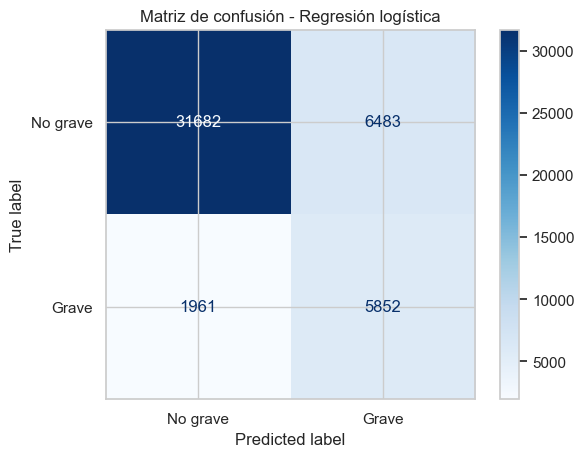

In [13]:
log_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=None)),
])

log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("Regresión logística")
print("Accuracy:", round(accuracy_score(y_test, log_pred), 4))
print(classification_report(y_test, log_pred, target_names=["No grave", "Grave"]))

ConfusionMatrixDisplay.from_predictions(y_test, log_pred, display_labels=["No grave", "Grave"], cmap="Blues")
plt.title("Matriz de confusión - Regresión logística")
plt.show()

### Explicación

En esta celda entreno una regresión logística como modelo base. Este modelo me sirve porque es sencillo de interpretar y permite tener una primera comparación para saber que tan bien se puede clasificar la gravedad de los accidentes. Después evaluo sus resultados con accuracy, reporte de clasificación y matriz de confusión.

### Interpretacion

La matriz de confusion de la regresion logistica muestra que el modelo logra una accuracy de 0.8163. Identifica correctamente muchos accidentes no graves y alcanza un recall de 0.75 para la clase grave, aunque con una precision menor en esa clase. Como modelo base, sirve para tener una referencia inicial y para comparar contra un metodo mas fuerte.

El valor principal de este modelo es que es mas sencillo de explicar. Sin embargo, para fines preventivos no basta con tener buena accuracy general; tambien importa detectar la mayor cantidad posible de accidentes graves, porque esos son los que tienen mayor impacto social.


Random Forest
Accuracy: 0.8633
              precision    recall  f1-score   support

    No grave       0.93      0.90      0.92     38165
       Grave       0.58      0.69      0.63      7813

    accuracy                           0.86     45978
   macro avg       0.76      0.80      0.77     45978
weighted avg       0.87      0.86      0.87     45978



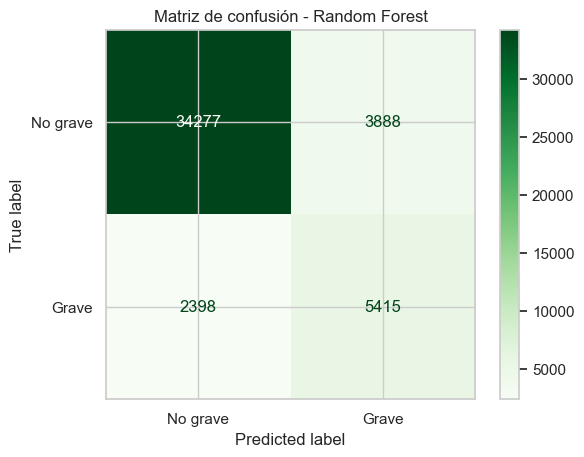

In [14]:
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        min_samples_leaf=3,
        n_jobs=-1,
    )),
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print(classification_report(y_test, rf_pred, target_names=["No grave", "Grave"]))

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=["No grave", "Grave"], cmap="Greens")
plt.title("Matriz de confusión - Random Forest")
plt.show()

### Explicación

Aquí entreno un modelo Random Forest para clasificar accidentes graves y no graves. Este modelo combina varios árboles de decisión y suele tener mejor rendimiento que un modelo simple. Uso pesos balanceados para ayudar al modelo cuando una clase aparece más que la otra, y después reviso sus metricas con el mismo conjunto de prueba.

### Interpretacion

La matriz de confusion del Random Forest muestra mejor desempeno general que la regresion logistica, con accuracy de 0.8633. Para la clase grave obtiene una precision de 0.58 y un recall de 0.69, lo que significa que mejora la calidad de las clasificaciones positivas, aunque detecta una proporcion menor de graves que la regresion logistica. Por eso funciona como un modelo mas equilibrado para el proyecto.

Aun asi, el resultado debe interpretarse como apoyo para encontrar patrones, no como una herramienta para predecir accidentes futuros con total exactitud. Su utilidad principal esta en mostrar que variables ayudan mas a distinguir entre accidentes graves y no graves.


### Regla IF-THEN del Arbol de Decision

Para cubrir el requisito del arbol de decision, entreno un arbol pequeno e interpretable. La regla IF-THEN no reemplaza al Random Forest; sirve para explicar una ruta sencilla que el modelo usa para separar accidentes graves y no graves.


In [15]:
tree_rule_model = Pipeline([
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(max_depth=3, min_samples_leaf=100, random_state=42)),
])

tree_rule_model.fit(X_train, y_train)
tree_rule_pred = tree_rule_model.predict(X_test)

print("Arbol de Decision interpretable")
print("Accuracy:", round(accuracy_score(y_test, tree_rule_pred), 4))
print(classification_report(y_test, tree_rule_pred, target_names=["No grave", "Grave"]))

rule_feature_names = list(tree_rule_model.named_steps["preprocess"].get_feature_names_out())
tree_rules = export_text(
    tree_rule_model.named_steps["model"],
    feature_names=rule_feature_names,
    max_depth=3,
)

print("Regla IF-THEN extraida del arbol:")
print(tree_rules)


Arbol de Decision interpretable
Accuracy: 0.8727
              precision    recall  f1-score   support

    No grave       0.91      0.95      0.92     38165
       Grave       0.66      0.52      0.58      7813

    accuracy                           0.87     45978
   macro avg       0.78      0.73      0.75     45978
weighted avg       0.86      0.87      0.87     45978

Regla IF-THEN extraida del arbol:
|--- cat__TIPACCID_Colisión con peatón (atropellamiento) <= 0.50
|   |--- num__INVOLUCRA_MOTO <= 1.16
|   |   |--- num__INVOLUCRA_BICI <= 3.65
|   |   |   |--- class: 0
|   |   |--- num__INVOLUCRA_BICI >  3.65
|   |   |   |--- class: 1
|   |--- num__INVOLUCRA_MOTO >  1.16
|   |   |--- cat__NOM_MUNICIPIO_Cajeme <= 0.50
|   |   |   |--- class: 1
|   |   |--- cat__NOM_MUNICIPIO_Cajeme >  0.50
|   |   |   |--- class: 0
|--- cat__TIPACCID_Colisión con peatón (atropellamiento) >  0.50
|   |--- class: 1



### Interpretacion

La regla IF-THEN permite explicar el modelo en lenguaje de decision: si se cumplen ciertas condiciones de tipo de accidente, region, horario u otras variables codificadas, el arbol dirige el caso hacia una clase de gravedad. Esta lectura es menos potente que el Random Forest, pero es mas transparente para comunicar hallazgos preventivos.


In [16]:
model_comparison = pd.DataFrame([
    {
        "modelo": "KNN linea base",
        "accuracy": accuracy_score(y_knn_test, knn_pred),
        "precision_grave": precision_score(y_knn_test, knn_pred, zero_division=0),
        "recall_grave": recall_score(y_knn_test, knn_pred, zero_division=0),
        "f1_grave": f1_score(y_knn_test, knn_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_knn_test, knn_score),
    },
    {
        "modelo": "Regresion Logistica",
        "accuracy": accuracy_score(y_test, log_pred),
        "precision_grave": precision_score(y_test, log_pred, zero_division=0),
        "recall_grave": recall_score(y_test, log_pred, zero_division=0),
        "f1_grave": f1_score(y_test, log_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1]),
    },
    {
        "modelo": "Random Forest",
        "accuracy": accuracy_score(y_test, rf_pred),
        "precision_grave": precision_score(y_test, rf_pred, zero_division=0),
        "recall_grave": recall_score(y_test, rf_pred, zero_division=0),
        "f1_grave": f1_score(y_test, rf_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]),
    },
    {
        "modelo": "Arbol IF-THEN",
        "accuracy": accuracy_score(y_test, tree_rule_pred),
        "precision_grave": precision_score(y_test, tree_rule_pred, zero_division=0),
        "recall_grave": recall_score(y_test, tree_rule_pred, zero_division=0),
        "f1_grave": f1_score(y_test, tree_rule_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, tree_rule_model.predict_proba(X_test)[:, 1]),
    },
]).round(4)

display(model_comparison.sort_values("f1_grave", ascending=False))


,modelo,accuracy,precision_grave,recall_grave,f1_grave,roc_auc
2,Random Forest,0.8633,0.5821,0.6931,0.6327,0.8871
1,Regresion Logistica,0.8163,0.4744,0.7490,0.5809,0.8759
3,Arbol IF-THEN,0.8727,0.6597,0.5182,0.5805,0.7495
0,KNN linea base,0.8615,0.6615,0.3785,0.4815,0.7791


### Interpretacion comparativa

La comparativa incorpora KNN linea base y el Arbol IF-THEN para cumplir los metodos del curso. La recomendacion final se mantiene en Random Forest cuando ofrece mejor balance para la clase grave, mientras que KNN y el arbol interpretable funcionan como referencias tecnicas y explicativas.


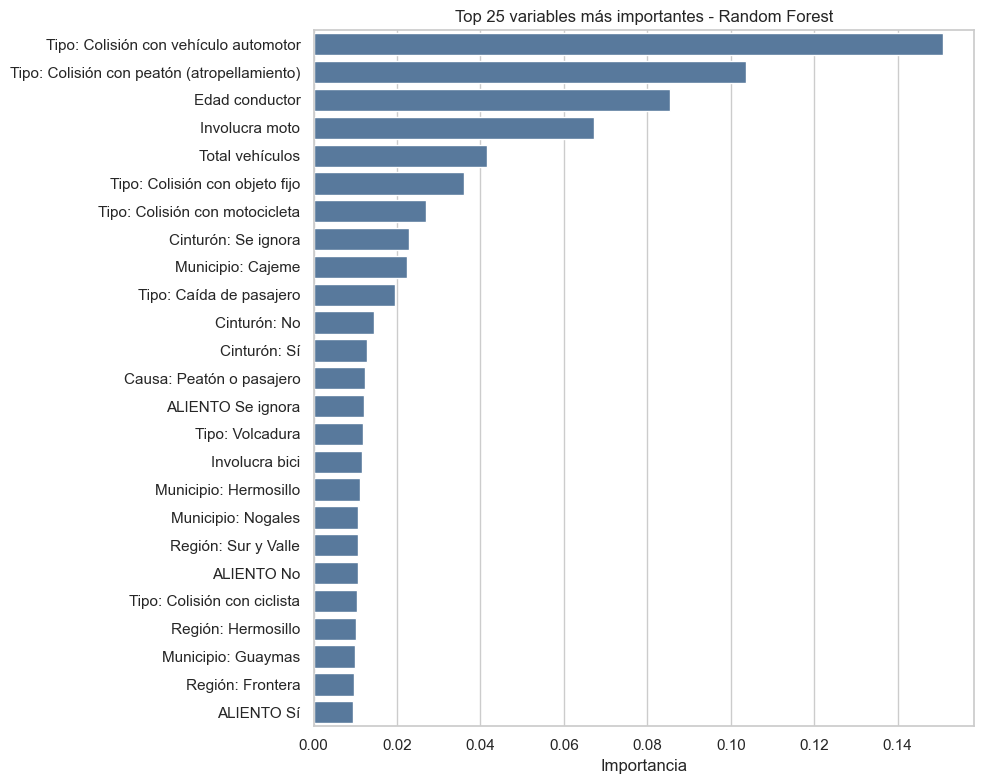

,variable_limpia,variable,importancia
78,Tipo: Colisión con vehículo automotor,cat__TIPACCID_Colisión con vehículo automotor,0.150751
77,Tipo: Colisión con peatón (atropellamiento),cat__TIPACCID_Colisión con peatón (atropellami...,0.103524
99,Edad conductor,num__EDAD_CONDUCTOR,0.085364
101,Involucra moto,num__INVOLUCRA_MOTO,0.067185
100,Total vehículos,num__TOTAL_VEHICULOS,0.041658
76,Tipo: Colisión con objeto fijo,cat__TIPACCID_Colisión con objeto fijo,0.036027
75,Tipo: Colisión con motocicleta,cat__TIPACCID_Colisión con motocicleta,0.027035
97,Cinturón: Se ignora,cat__CINTURON_Se ignora,0.022894
15,Municipio: Cajeme,cat__NOM_MUNICIPIO_Cajeme,0.022368
71,Tipo: Caída de pasajero,cat__TIPACCID_Caída de pasajero,0.019406


In [17]:
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_
importance_df = (
    pd.DataFrame({"variable": feature_names, "importancia": importances})
    .sort_values("importancia", ascending=False)
    .head(25)
)
importance_df["variable_limpia"] = (
    importance_df["variable"]
    .str.replace(r"^(cat|num)__", "", regex=True)
    .str.replace("onehot__", "", regex=False)
    .str.replace("TIPACCID_", "Tipo: ", regex=False)
    .str.replace("CAUSAACCI_", "Causa: ", regex=False)
    .str.replace("REGION_", "Región: ", regex=False)
    .str.replace("NOM_MUNICIPIO_", "Municipio: ", regex=False)
    .str.replace("RANGO_HORA_", "Horario: ", regex=False)
    .str.replace("DIASEMANA_", "Día: ", regex=False)
    .str.replace("CINTURON_", "Cinturón: ", regex=False)
    .str.replace("TOTAL_VEHICULOS", "Total vehículos", regex=False)
    .str.replace("INVOLUCRA_MOTO", "Involucra moto", regex=False)
    .str.replace("INVOLUCRA_BICI", "Involucra bici", regex=False)
    .str.replace("EDAD_CONDUCTOR", "Edad conductor", regex=False)
    .str.replace("_", " ", regex=False)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, y="variable_limpia", x="importancia", color="#4C78A8")
plt.title("Top 25 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(importance_df[["variable_limpia", "variable", "importancia"]])

### Explicación

En esta parte reviso la importancia de las variables del Random Forest. Extraigo los nombres de las variables después del preprocesamiento y las ordeno según su aporte al modelo. Esta gráfica me ayuda a identificar que factores tienen más peso al clasificar la gravedad, como región, tipo de accidente, causa u horario.

### Interpretacion

La grafica de importancia de variables muestra que el tipo de accidente tiene mucho peso en la clasificacion de gravedad. Las variables mas importantes son la colision con vehiculo automotor, la colision con peaton, la edad del conductor, la presencia de motocicleta y el total de vehiculos involucrados. Tambien aparecen variables relacionadas con cinturon, municipio, causa probable, aliento y region.

Esto tiene sentido desde el punto de vista preventivo: no todos los accidentes tienen el mismo nivel de riesgo. Los atropellamientos, motocicletas, ciertos tipos de colision y las caracteristicas del contexto pueden generar mas lesionados o fallecidos, por lo que deben tratarse como focos prioritarios en las recomendaciones.


## 10. Clustering jerárquico de municipios

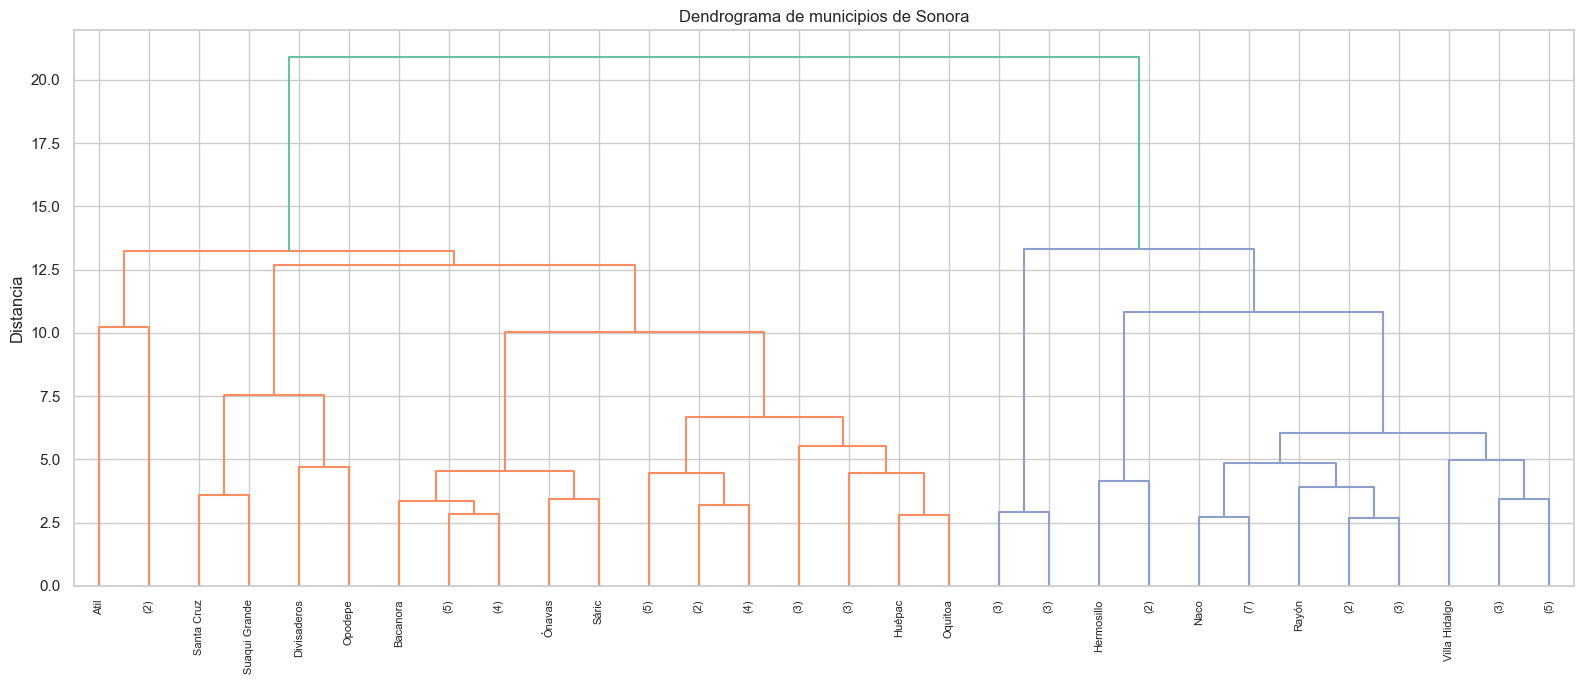

,ID_MUNICIPIO,NOM_MUNICIPIO,REGION,accidentes,pct_graves,heridos_prom,muertos_prom,pct_moto,pct_bici,vehiculos_prom,pct_tipo_Colisión con vehículo automotor,pct_tipo_Colisión con motocicleta,pct_tipo_Colisión con objeto fijo,pct_tipo_Colisión con peatón (atropellamiento),pct_tipo_Volcadura,pct_tipo_Salida del camino,CLUSTER
61,064,Trincheras,Costa y desierto,2,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1
6,007,Atil,Costa y desierto,1,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1
7,008,Bacadéhuachi,Sierra,1,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1
40,041,Nacozari de García,Frontera,673,0.142645,0.208024,0.008915,0.017831,0.001486,1.554235,0.490342,0.005944,0.145617,0.010401,0.144131,0.157504,2
37,038,Moctezuma,Centro,509,0.086444,0.092338,0.029470,0.027505,0.000000,1.442043,0.388998,0.015717,0.123772,0.011788,0.180747,0.192534,2
26,027,Fronteras,Frontera,476,0.226891,0.292017,0.039916,0.033613,0.002101,1.403361,0.331933,0.014706,0.109244,0.018908,0.220588,0.216387,2
22,023,Cumpas,Centro,452,0.203540,0.334071,0.030973,0.061947,0.002212,1.440265,0.358407,0.039823,0.092920,0.013274,0.254425,0.126106,2
5,006,Arizpe,Centro,240,0.158333,0.191667,0.033333,0.020833,0.004167,1.220833,0.183333,0.012500,0.154167,0.008333,0.391667,0.170833,2
50,051,Rosario,Sur y Valle,233,0.253219,0.381974,0.047210,0.111588,0.004292,1.351931,0.197425,0.051502,0.103004,0.021459,0.369099,0.128755,2
10,011,Bacoachi,Sierra,158,0.316456,0.405063,0.044304,0.037975,0.000000,1.297468,0.240506,0.000000,0.050633,0.000000,0.481013,0.126582,2


In [18]:
municipal = (
    atus.groupby(["ID_MUNICIPIO", "NOM_MUNICIPIO", "REGION"])
    .agg(
        accidentes=("GRAVE_BIN", "size"),
        pct_graves=("GRAVE_BIN", "mean"),
        heridos_prom=("TOTAL_HERIDOS", "mean"),
        muertos_prom=("TOTAL_MUERTOS", "mean"),
        pct_moto=("INVOLUCRA_MOTO", "mean"),
        pct_bici=("INVOLUCRA_BICI", "mean"),
        vehiculos_prom=("TOTAL_VEHICULOS", "mean"),
    )
    .reset_index()
)

top_tipos = atus["TIPACCID"].value_counts().head(6).index.tolist()
tipo_pivot = (
    pd.crosstab(atus["ID_MUNICIPIO"], atus["TIPACCID"], normalize="index")
    .reindex(columns=top_tipos, fill_value=0)
    .add_prefix("pct_tipo_")
    .reset_index()
)

municipal = municipal.merge(tipo_pivot, on="ID_MUNICIPIO", how="left").fillna(0)

cluster_features = [
    "accidentes", "pct_graves", "heridos_prom", "muertos_prom", "pct_moto",
    "pct_bici", "vehiculos_prom"
] + [c for c in municipal.columns if c.startswith("pct_tipo_")]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(municipal[cluster_features])

Z = linkage(X_cluster, method="ward")

plt.figure(figsize=(16, 7))
dendrogram(
    Z,
    labels=municipal["NOM_MUNICIPIO"].values,
    leaf_rotation=90,
    leaf_font_size=8,
    truncate_mode="lastp",
    p=30,
    show_leaf_counts=True,
)
plt.title("Dendrograma de municipios de Sonora")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

municipal["CLUSTER"] = fcluster(Z, t=4, criterion="maxclust")
display(municipal.sort_values(["CLUSTER", "accidentes"], ascending=[True, False]))

### Explicación

Aquí aplico clustering jerárquico para agrupar municipios con comportamientos parecidos. Primero creo indicadores por municipio, como total de accidentes, porcentaje de accidentes graves, promedio de heridos, promedio de fallecidos y presencia de motocicletas o bicicletas. Después estandarizo las variables y genero un dendrograma para visualizar que municipios se parecen entre si.

### Interpretacion

El dendrograma y los clusters agrupan municipios con comportamientos parecidos. El cluster 4 concentra casi todo el volumen de accidentes, con municipios como Hermosillo, Cajeme, San Luis Rio Colorado, Guaymas, Puerto Penasco, Nogales, Caborca y Cananea. Estos municipios requieren acciones preventivas amplias por la cantidad de casos registrados.

El cluster 3 agrupa municipios del Sur y Valle con menor volumen que los grandes centros, pero con porcentajes de gravedad altos, como Empalme, Navojoa, Bacum, Etchojoa, San Ignacio Rio Muerto y Alamos. Tambien aparece un cluster pequeno con municipios de muy pocos registros y 100% de gravedad; ese resultado debe interpretarse con cautela porque se basa en uno o dos accidentes. En conjunto, el clustering muestra que la prevencion no debe basarse solo en cantidad de accidentes, sino tambien en la gravedad proporcional y el perfil de cada municipio.


## 11. Análisis temporal y series de tiempo exploratorias

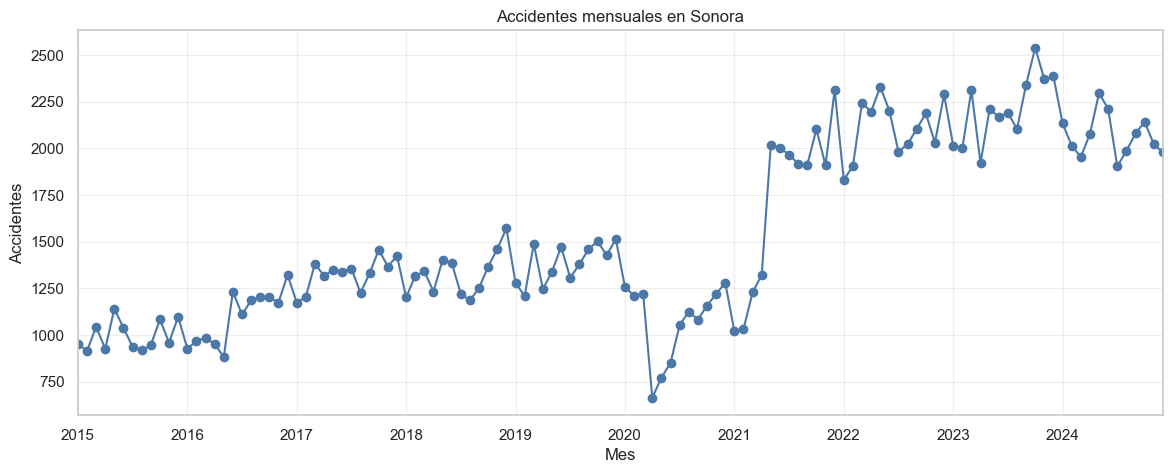

count     120.000000
mean     1532.591667
std       476.977502
min       664.000000
25%      1185.750000
50%      1361.500000
75%      2005.000000
max      2539.000000
Name: accidentes, dtype: float64

In [19]:
monthly = (
    atus.dropna(subset=["FECHA_MES"])
    .groupby("FECHA_MES")
    .size()
    .asfreq("MS", fill_value=0)
    .rename("accidentes")
)

plt.figure(figsize=(14, 5))
monthly.plot(marker="o", color="#4C78A8")
plt.title("Accidentes mensuales en Sonora")
plt.xlabel("Mes")
plt.ylabel("Accidentes")
plt.grid(True, alpha=0.3)
plt.show()

display(monthly.describe())

### Explicación

En esta celda construyo una serie mensual de accidentes. Agrupo los registros por mes, completo los meses faltantes con cero si fuera necesario y grafico la evolución en el tiempo. Esto me permite observar si hay aumentos, disminuciones o periodos donde los accidentes se concentran más.

### Interpretacion

La serie mensual muestra cambios claros a lo largo del tiempo. El mes con menos accidentes es abril de 2020, con 664 casos, lo cual coincide con un periodo de menor movilidad. El punto mas alto aparece en octubre de 2023, con 2,539 accidentes. En general, el promedio mensual del periodo es de aproximadamente 1,532.59 accidentes.

Esta grafica ayuda a identificar meses de mayor presion vial y permite pensar en campanas preventivas por temporada. Tambien muestra que despues de 2020 los accidentes vuelven a subir de forma importante, especialmente durante 2021, 2022 y 2023, antes de una ligera reduccion en 2024.


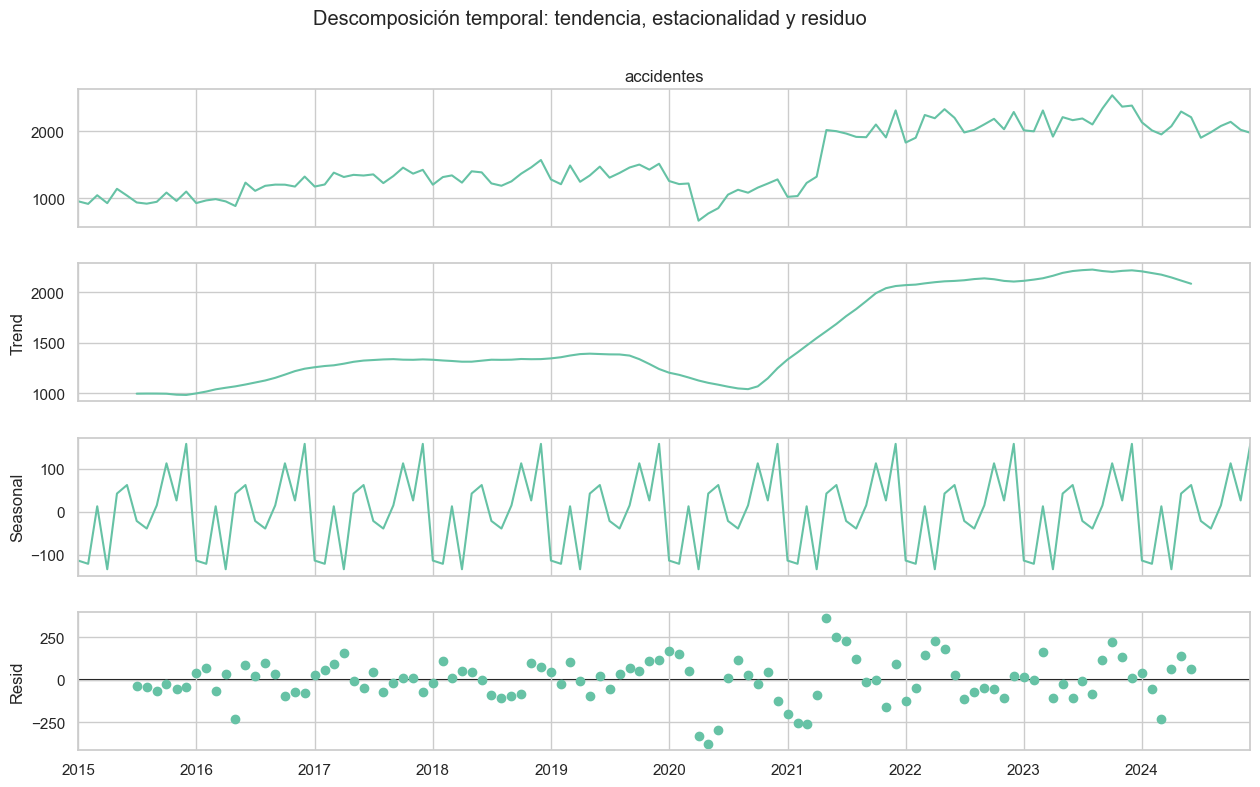

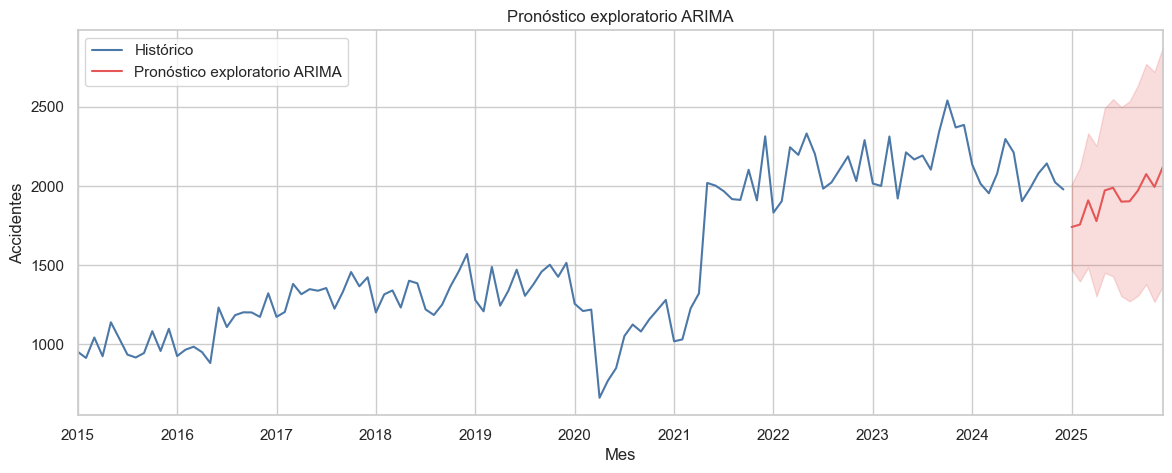

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

if len(monthly) >= 24:
    decomposition = seasonal_decompose(monthly, model="additive", period=12)
    fig = decomposition.plot()
    fig.set_size_inches(14, 8)
    plt.suptitle("Descomposición temporal: tendencia, estacionalidad y residuo", y=1.02)
    plt.show()

    arima_model = SARIMAX(
        monthly,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    arima_fit = arima_model.fit(disp=False)
    forecast = arima_fit.get_forecast(steps=12)
    forecast_mean = forecast.predicted_mean
    forecast_ci = forecast.conf_int()

    plt.figure(figsize=(14, 5))
    monthly.plot(label="Histórico", color="#4C78A8")
    forecast_mean.plot(label="Pronóstico exploratorio ARIMA", color="#E45756")
    plt.fill_between(
        forecast_ci.index,
        forecast_ci.iloc[:, 0],
        forecast_ci.iloc[:, 1],
        color="#E45756",
        alpha=0.2,
    )
    plt.title("Pronóstico exploratorio ARIMA")
    plt.xlabel("Mes")
    plt.ylabel("Accidentes")
    plt.legend()
    plt.show()
else:
    print("No hay suficientes meses para descomposición o ARIMA.")

### Explicación

Aquí hago un análisis temporal más avanzado. Si la serie tiene suficientes meses, la descompongo en tendencia, estacionalidad y residuo para entender mejor su comportamiento. También ajusto un modelo ARIMA estacional para generar un pronóstico exploratorio de los siguientes meses. Lo uso como complemento, no como una predicción definitiva.

### Interpretación

La descomposición temporal permite separar la serie en tendencia, estacionalidad y residuo. Con esto puedo observar si el comportamiento mensual tiene un patrón repetitivo o si hay cambios generales a lo largo del tiempo. El modelo ARIMA se usa como una exploración para ver la posible continuidad de la serie.

Este pronóstico no debe tomarse como una predicción exacta, sino como una herramienta de apoyo. Su utilidad es mostrar si la tendencia podría mantenerse y ayudar a planear acciones preventivas antes de periodos con posible aumento de accidentes.

22:58:33 - cmdstanpy - INFO - Chain [1] start processing
22:58:33 - cmdstanpy - INFO - Chain [1] done processing


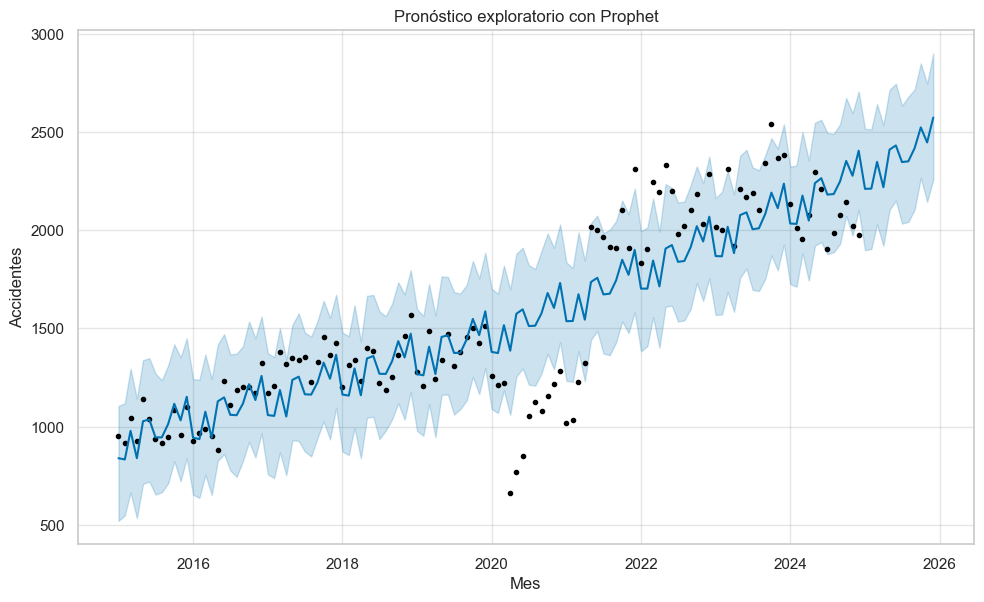

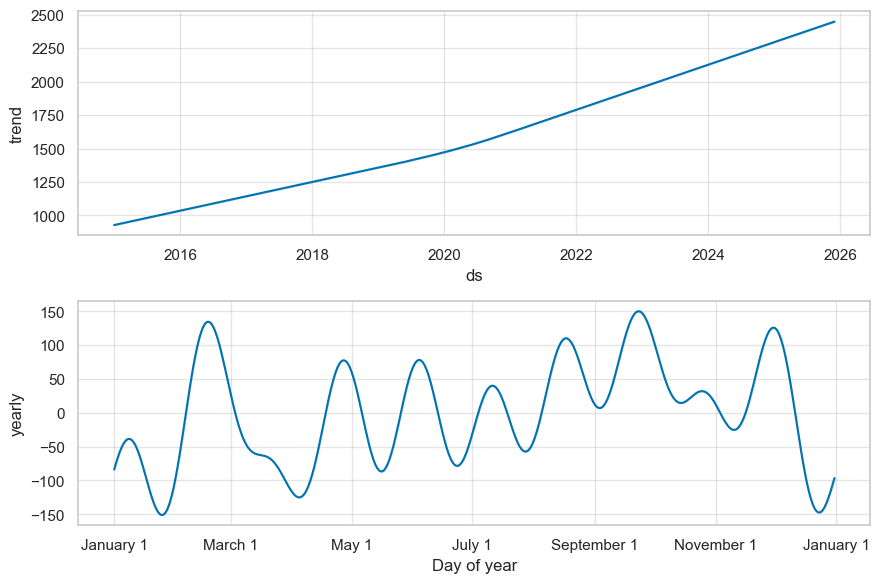

In [21]:
# Prophet es opcional. Si no esta instalado, esta celda no detiene el notebook.
try:
    from prophet import Prophet

    prophet_df = monthly.reset_index()
    prophet_df.columns = ["ds", "y"]

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(prophet_df)
    future = m.make_future_dataframe(periods=12, freq="MS")
    forecast = m.predict(future)

    fig1 = m.plot(forecast)
    plt.title("Pronóstico exploratorio con Prophet")
    plt.xlabel("Mes")
    plt.ylabel("Accidentes")
    plt.show()

    fig2 = m.plot_components(forecast)
    plt.show()
except Exception as exc:
    print("Prophet no está disponible o no pudo ejecutarse en este entorno.")
    print("Detalle:", exc)

### Explicacion

En esta ultima celda incorporo Prophet como una alternativa adicional para modelar la serie mensual. Si la libreria esta disponible, el modelo se entrena con los accidentes por mes, genera un pronostico exploratorio y muestra dos salidas graficas.

La primera grafica muestra la serie historica junto con el pronostico. Los puntos representan los valores mensuales observados, la linea muestra la estimacion del modelo y la franja sombreada representa el intervalo de incertidumbre. Esta grafica sirve para revisar si Prophet sigue de forma razonable la trayectoria general de los accidentes y como proyecta los siguientes meses.

La segunda grafica muestra los componentes del modelo. En ella se separa la tendencia general de largo plazo y la estacionalidad anual. Esto ayuda a distinguir si el cambio se debe a un aumento o disminucion sostenida en el tiempo, o si hay meses que normalmente presentan niveles mas altos o mas bajos de accidentes.

La celda esta protegida con `try/except` para que el notebook pueda continuar aunque Prophet no este instalado o falle en el entorno de ejecucion.


### Interpretacion

Prophet funciona como una segunda lectura del comportamiento temporal. En la grafica principal, los puntos historicos permiten comparar los datos reales contra la linea ajustada por el modelo. Si la linea sigue de cerca los puntos, significa que el modelo captura bien la forma general de la serie; si se separa mucho, entonces el pronostico debe tomarse con mayor cautela. La franja sombreada muestra la incertidumbre: mientras mas amplia sea, menos confianza hay en el valor exacto del pronostico.

La grafica de componentes ayuda a explicar de donde viene el pronostico. La tendencia permite observar si, despues de la caida de 2020, la serie mantiene un comportamiento de recuperacion o crecimiento. La estacionalidad anual permite identificar meses donde Prophet estima aumentos o disminuciones recurrentes. Esto es util para planear campanas preventivas antes de periodos donde historicamente podria subir la cantidad de accidentes.

Por eso, Prophet no se interpreta como la fuente principal de conclusiones, sino como una validacion complementaria. Si sus resultados coinciden con la serie historica, la descomposicion temporal y SARIMA, refuerzan la idea de anticipar acciones por temporada. Si difieren, la diferencia debe tomarse como una senal para revisar supuestos, calidad de datos y posibles factores externos antes de convertir el pronostico en una decision preventiva.


## 12. Interpretacion preventiva

Con base en el analisis realizado, puedo concluir que los accidentes de transito en Sonora se concentran principalmente en las regiones de Hermosillo, Sur y Valle, y Frontera. Hermosillo tiene el mayor numero total de accidentes, con 65,252 registros, pero regiones como Sierra, Centro y Sur y Valle presentan porcentajes de gravedad mas altos. Esto significa que la prevencion debe considerar tanto la cantidad de accidentes como la proporcion de accidentes con heridos o fallecidos.

El tipo de accidente mas comun es la colision con vehiculo automotor, con 125,202 casos. Tambien destacan las colisiones con motocicleta, con 18,531 casos, las colisiones con objeto fijo, con 17,205, y los atropellamientos, con 6,833. La causa probable mas frecuente es Conductor, con 178,145 registros, por lo que una parte importante de la prevencion debe enfocarse en comportamiento vial: exceso de velocidad, distracciones, no respetar senalamientos, distancia entre vehiculos y conduccion riesgosa.

Las reglas de asociacion muestran que los atropellamientos tienen una relacion fuerte con accidentes graves: la regla de colision con peaton hacia gravedad alta tiene confianza de 1.0 y lift de 5.88. Por eso, una recomendacion preventiva seria reforzar la proteccion peatonal mediante cruces seguros, senalizacion visible, control de velocidad y vigilancia en zonas de alta movilidad peatonal.

El analisis temporal indica que las tardes de fin de semana son ventanas criticas. La tarde del sabado concentra 10,952 accidentes y la tarde del viernes 10,802, por lo que ambas deben considerarse en operativos y campanas. Ademas, el mes con mas registros fue octubre de 2023, con 2,539 accidentes. Esto sugiere que las campanas de prevencion y los operativos de vigilancia pueden ser mas efectivos si se aplican en horarios y periodos de alta movilidad.

El Random Forest tuvo mejor desempeno general que la regresion logistica, con accuracy de 0.8633 frente a 0.8163. Sin embargo, la regresion logistica tuvo mayor recall para accidentes graves, mientras que Random Forest ofrecio un equilibrio mas estable entre precision y recall. Ademas, la importancia de variables mostro que el tipo de accidente, la edad del conductor, la presencia de motocicleta, el total de vehiculos involucrados, el cinturon, el municipio y la region ayudan a clasificar la gravedad.

El clustering jerarquico muestra que hay municipios con perfiles distintos. Algunos tienen muchos accidentes, como Hermosillo, Cajeme y San Luis Rio Colorado. Otros tienen menos accidentes, pero mayor proporcion de gravedad, como Empalme, Navojoa, Bacum, Etchojoa, San Ignacio Rio Muerto y Alamos. Por eso, no conviene aplicar una sola estrategia para todo el estado; cada region necesita medidas segun su propio patron.

Como propuesta general, para Hermosillo y los municipios con alto volumen de accidentes se recomiendan campanas masivas de educacion vial, control de velocidad y vigilancia en cruces conflictivos. Para Sur y Valle se recomienda atender accidentes graves, motocicletas y traslados entre municipios. Para Frontera se recomienda reforzar vigilancia en zonas de flujo vehicular y comercial. Para regiones con menor cantidad de accidentes pero mayor gravedad proporcional, como Sierra y Centro, conviene revisar condiciones de caminos, atencion a emergencias y senalizacion preventiva.

En conclusion, el proyecto muestra que los datos historicos permiten identificar patrones utiles para la prevencion vial. El objetivo no es solamente contar accidentes, sino reconocer donde ocurren, que tipo de accidentes predominan, que factores se relacionan con la gravedad y que acciones pueden aplicarse de manera mas enfocada en cada region de Sonora.
